In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

## Notebook 00 - Setup

Instala dependências, confirma o device disponível e visualiza amostra do dataset (**PneumoniaMNIST, versão 128x128**). Toda a lógica de carregar o dataset fica em `utils.get_dataloaders` - os notebooks seguintes chamam essa função, nunca redefinem transform/dataset/loader.

| Notebook | O que fazemos | Pergunta que responde |
|---|---|---|
| 00 | Dados | Com o que estamos trabalhando? |
| 01 | Teacher | Qual é o modelo "professor"? |
| 02 | Student baseline | Até onde o modelo pequeno vai sozinho? |
| 03 | KD | O professor ajuda? Quanto? Com quais T e α? |
| 04 | Avaliação | Vale a pena? (qualidade vs. custo) |

In [2]:
import os
# root = "/content/drive/MyDrive/testes"
# os.chdir(root)

In [3]:
!pip install torch torchvision medmnist matplotlib scikit-learn seaborn -q


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import torch, torchvision, medmnist
import matplotlib.pyplot as plt
import utils

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("MedMNIST:", medmnist.__version__)

PyTorch: 2.14.1+cu126
Torchvision: 0.29.1+cu126
MedMNIST: 3.0.2


`size=128` está definido em `get_dataloaders`, por isso baixa a versão 128x128 do PneumoniaMNIST (em vez do padrão 28x28). O arquivo fica em `./data` e é baixado uma única vez - os outros notebooks reaproveitam o mesmo cache.

In [5]:
loaders = utils.get_dataloaders(splits=("train", "val", "test"), batch_size=32)

train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))
print("Batches de teste:", len(test_loader))

Batches de treino: 76
Batches de validação: 9
Batches de teste: 15


![Resolution example](images/resolution_example.png)

In [6]:
device = utils.get_device()
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2070


### Distribuição das classes

Lemos só os **rótulos** (`get_labels`), sem carregar nem transformar as imagens.

In [7]:
def class_distribution(dataset, name):
    counts = np.bincount(utils.get_labels(dataset))
    print(f"\n{name}")
    for label, count in enumerate(counts):
        print(f"{'Normal' if label == 0 else 'Pneumonia'}: {count} ({count / counts.sum() * 100:.2f}%)")

class_distribution(train_loader.dataset, "TRAIN (balanceado)")
class_distribution(val_loader.dataset, "VALIDATION (balanceado)")
class_distribution(test_loader.dataset, "TEST (balanceado)")


TRAIN (balanceado)
Normal: 1214 (50.00%)
Pneumonia: 1214 (50.00%)

VALIDATION (balanceado)
Normal: 135 (50.00%)
Pneumonia: 135 (50.00%)

TEST (balanceado)
Normal: 234 (50.00%)
Pneumonia: 234 (50.00%)


#### Por que balanceamos?

O PneumoniaMNIST original tem muito mais casos de pneumonia do que normais. Veja o teste sem balanceamento:

In [8]:
test_original = utils.get_dataloaders(splits=("test",), balance=())["test"]
class_distribution(test_original.dataset, "TEST (original)")


TEST (original)
Normal: 234 (37.50%)
Pneumonia: 390 (62.50%)


Num teste desbalanceado, um modelo que pode tender a responder "Pneumonia" e teria a accuracy igual à proporção da classe majoritária. Com o teste 50/50, o "chute" vale 50% e a accuracy fica mais fácil de interpretar. *(Atenção: os números do curso valem para o teste balanceado, não para a distribuição real do hospital.)*

In [9]:
image, label = train_loader.dataset[0]
print("Shape da imagem:", image.shape)
print("Label:", label)

Shape da imagem: torch.Size([1, 128, 128])
Label: [0]


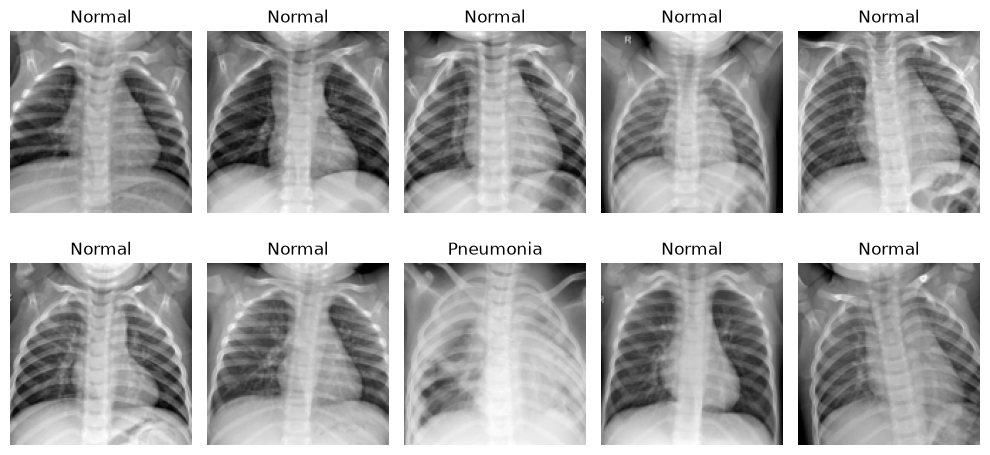

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax in axes.flat:
    image, label = train_loader.dataset[torch.randint(len(train_loader.dataset), (1,)).item()]
    ax.imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    ax.set_title("Pneumonia" if label.item() == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()

![Resolution example](images/pneumoniaMNIST.png)

## Notebook 01 - Treinamento do teacher

Constrói e treina o teacher (ResNet18 adaptada). É o modelo mais pesado do curso. Para treinar do zero, basta mudar a flag

#### Adaptações da ResNet18

- `conv1`: de 3 canais (RGB) para **1 canal** (raio-X em escala de cinza)
- `fc`: de 1000 classes (ImageNet) para **2 classes** (Normal / Pneumonia)

In [11]:
import torch.nn as nn

TRAIN_TEACHER = True   # True = treina do zero (CPU: ~20 min por época)
criterion = nn.CrossEntropyLoss()
epochs = 20

if TRAIN_TEACHER:
    teacher = utils.Teacher().to(device)
    optimizer_teacher = torch.optim.Adam(teacher.parameters(), lr=1e-3)
    history_teacher = utils.train_teacher_and_student_baseline(teacher, train_loader, val_loader, epochs, criterion,
                                             optimizer_teacher, device)
    utils.save_weights(teacher, "weights/teacher.pth")

teacher = utils.load_teacher("weights/teacher.pth", device)

Epoch 1/20 | Train Loss: 0.1980 | Train Acc: 0.9279 | Val Loss: 0.2059 | Val Acc: 0.9000
Epoch 2/20 | Train Loss: 0.1006 | Train Acc: 0.9613 | Val Loss: 0.0858 | Val Acc: 0.9704
Epoch 3/20 | Train Loss: 0.0731 | Train Acc: 0.9728 | Val Loss: 0.3028 | Val Acc: 0.8815
Epoch 4/20 | Train Loss: 0.0485 | Train Acc: 0.9786 | Val Loss: 0.0767 | Val Acc: 0.9630
Epoch 5/20 | Train Loss: 0.0420 | Train Acc: 0.9893 | Val Loss: 0.0747 | Val Acc: 0.9741
Epoch 6/20 | Train Loss: 0.0482 | Train Acc: 0.9823 | Val Loss: 0.2863 | Val Acc: 0.9148
Epoch 7/20 | Train Loss: 0.0285 | Train Acc: 0.9893 | Val Loss: 0.1543 | Val Acc: 0.9519
Epoch 8/20 | Train Loss: 0.0253 | Train Acc: 0.9876 | Val Loss: 0.1353 | Val Acc: 0.9593
Epoch 9/20 | Train Loss: 0.0170 | Train Acc: 0.9955 | Val Loss: 0.0813 | Val Acc: 0.9741
Epoch 10/20 | Train Loss: 0.0354 | Train Acc: 0.9889 | Val Loss: 0.0911 | Val Acc: 0.9704
Epoch 11/20 | Train Loss: 0.0161 | Train Acc: 0.9946 | Val Loss: 0.0484 | Val Acc: 0.9741
Epoch 12/20 | Train

In [12]:
for nome, loader in [("train", train_loader), ("val", val_loader)]:
    loss, acc = utils.validate(teacher, loader, criterion, device)
    print(f"Teacher {nome}: loss {loss:.4f} | acc {acc:.4f}")

Teacher train: loss 0.0000 | acc 1.0000
Teacher val: loss 0.1525 | acc 0.9741


In [13]:
teacher = utils.load_teacher("weights/teacher.pth", device)   # eval() 
print(f"Teacher: {utils.count_parameters(teacher):,} parâmetros | {utils.model_size_mb(teacher):.1f} MB")

Teacher: 11,171,266 parâmetros | 44.7 MB


## Notebook 02 - Student baseline (sem KD)

Treina o `SmallCNN` do zero, sem nenhuma ajuda do teacher. Esse será nosso **baseline**, que depois vamos comparar com os students treinados com KD no notebook 03.

> **Experimento controlado:** chamamos `set_seed(42)` antes de criar cada student. Assim todos começam com os **mesmos pesos** e veem os batches na **mesma ordem**; a única coisa que muda entre os modelos é o KD.

In [14]:
from utils import SmallCNN, compare_models, plot_history

In [15]:
utils.set_seed(42)
student = SmallCNN().to(device)
optimizer_student = torch.optim.Adam(student.parameters(), lr=1e-3)

In [16]:
history_baseline = utils.train_teacher_and_student_baseline(student, train_loader, val_loader, epochs, criterion,
                                             optimizer_student, device)

Epoch 1/20 | Train Loss: 0.6351 | Train Acc: 0.6483 | Val Loss: 0.6051 | Val Acc: 0.6519
Epoch 2/20 | Train Loss: 0.5375 | Train Acc: 0.7430 | Val Loss: 0.4755 | Val Acc: 0.8185
Epoch 3/20 | Train Loss: 0.4181 | Train Acc: 0.8200 | Val Loss: 0.3646 | Val Acc: 0.8519
Epoch 4/20 | Train Loss: 0.3300 | Train Acc: 0.8715 | Val Loss: 0.3025 | Val Acc: 0.9037
Epoch 5/20 | Train Loss: 0.2988 | Train Acc: 0.8871 | Val Loss: 0.3018 | Val Acc: 0.8667
Epoch 6/20 | Train Loss: 0.2871 | Train Acc: 0.8876 | Val Loss: 0.2781 | Val Acc: 0.9000
Epoch 7/20 | Train Loss: 0.3034 | Train Acc: 0.8826 | Val Loss: 0.2716 | Val Acc: 0.9037
Epoch 8/20 | Train Loss: 0.2776 | Train Acc: 0.8962 | Val Loss: 0.2896 | Val Acc: 0.9037
Epoch 9/20 | Train Loss: 0.2862 | Train Acc: 0.8925 | Val Loss: 0.2709 | Val Acc: 0.9074
Epoch 10/20 | Train Loss: 0.2762 | Train Acc: 0.8962 | Val Loss: 0.2722 | Val Acc: 0.8889
Epoch 11/20 | Train Loss: 0.2777 | Train Acc: 0.8962 | Val Loss: 0.2637 | Val Acc: 0.9000
Epoch 12/20 | Train

In [17]:
utils.save_weights(student, "weights/student_baseline.pth")
print("Student baseline salvo em weights/student_baseline.pth")

Student baseline salvo em weights/student_baseline.pth


## Notebook 03 - Knowledge Distillation (offline)

Usa o teacher já treinado (congelado) para orientar um novo modelo `SmallCNN`, treinado do zero. O teacher só gera logits a cada batch - nunca é atualizado.

### Temperature

Em Knowledge Distillation, a temperatura $T$ controla o quanto a distribuição de probabilidades é suavizada.

$$
p_i^{(T)} = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}
$$

- $T = 1$: distribuição original, mais "dura"
- $T > 1$: distribuição mais suave
- Quanto maior $T$, maior a suavização das probabilidades


In [18]:
utils.set_seed(42)
student_kd_4 = utils.SmallCNN().to(device)
optimizer_kd_4 = torch.optim.Adam(student_kd_4.parameters(), lr=1e-3)

history_student_kd_4 = utils.train_knowledge_distillation(
    teacher, student_kd_4, train_loader, val_loader, epochs,
    T=4, alpha=0.75, optimizer=optimizer_kd_4, device=device)

Epoch [1/20] Train Loss: 2.6247 Train Acc: 0.6166 Val Loss: 0.6162 Val Acc: 0.6407
Epoch [2/20] Train Loss: 2.3580 Train Acc: 0.7191 Val Loss: 0.5590 Val Acc: 0.7519
Epoch [3/20] Train Loss: 1.9487 Train Acc: 0.7982 Val Loss: 0.5000 Val Acc: 0.7667
Epoch [4/20] Train Loss: 1.5551 Train Acc: 0.8480 Val Loss: 0.4932 Val Acc: 0.8926
Epoch [5/20] Train Loss: 1.3244 Train Acc: 0.8793 Val Loss: 0.3751 Val Acc: 0.8593
Epoch [6/20] Train Loss: 1.2251 Train Acc: 0.8859 Val Loss: 0.4091 Val Acc: 0.9000
Epoch [7/20] Train Loss: 1.2800 Train Acc: 0.8793 Val Loss: 0.3633 Val Acc: 0.9037
Epoch [8/20] Train Loss: 1.1735 Train Acc: 0.8950 Val Loss: 0.4277 Val Acc: 0.8963
Epoch [9/20] Train Loss: 1.2019 Train Acc: 0.8909 Val Loss: 0.3669 Val Acc: 0.9074
Epoch [10/20] Train Loss: 1.1936 Train Acc: 0.8925 Val Loss: 0.3812 Val Acc: 0.8852
Epoch [11/20] Train Loss: 1.2050 Train Acc: 0.8892 Val Loss: 0.3510 Val Acc: 0.9000
Epoch [12/20] Train Loss: 1.1520 Train Acc: 0.8929 Val Loss: 0.3788 Val Acc: 0.8926
E

In [19]:
utils.save_weights(student_kd_4, "weights/student_kd_4.pth")
print("Student KD 4 salvo em weights/student_kd_4.pth")

Student KD 4 salvo em weights/student_kd_4.pth


#### Para fins comparativos, iremos treinar outro student com um valor diferente de temperature

In [20]:
utils.set_seed(42)
student_kd_10 = SmallCNN().to(device)
optimizer_kd_10 = torch.optim.Adam(student_kd_10.parameters(), lr=1e-3)


history_student_kd_10 = utils.train_knowledge_distillation(
    teacher, student_kd_10, train_loader, val_loader, epochs,
    T=10, alpha=0.75, optimizer=optimizer_kd_10, device=device)

Epoch [1/20] Train Loss: 5.9307 Train Acc: 0.5700 Val Loss: 0.6955 Val Acc: 0.6889
Epoch [2/20] Train Loss: 5.5290 Train Acc: 0.6775 Val Loss: 0.7251 Val Acc: 0.7333
Epoch [3/20] Train Loss: 4.9587 Train Acc: 0.7521 Val Loss: 0.5764 Val Acc: 0.7407
Epoch [4/20] Train Loss: 3.8541 Train Acc: 0.8093 Val Loss: 0.7338 Val Acc: 0.8333
Epoch [5/20] Train Loss: 2.8661 Train Acc: 0.8760 Val Loss: 0.4599 Val Acc: 0.8778
Epoch [6/20] Train Loss: 2.5278 Train Acc: 0.8909 Val Loss: 0.5984 Val Acc: 0.9000
Epoch [7/20] Train Loss: 2.6141 Train Acc: 0.8781 Val Loss: 0.4693 Val Acc: 0.8926
Epoch [8/20] Train Loss: 2.4221 Train Acc: 0.8937 Val Loss: 0.6080 Val Acc: 0.9037
Epoch [9/20] Train Loss: 2.4399 Train Acc: 0.8958 Val Loss: 0.4945 Val Acc: 0.8963
Epoch [10/20] Train Loss: 2.4323 Train Acc: 0.8970 Val Loss: 0.4791 Val Acc: 0.9000
Epoch [11/20] Train Loss: 2.4772 Train Acc: 0.8900 Val Loss: 0.4884 Val Acc: 0.8926
Epoch [12/20] Train Loss: 2.3777 Train Acc: 0.8979 Val Loss: 0.4923 Val Acc: 0.9037
E

In [21]:
utils.save_weights(student_kd_10, "weights/student_kd_10.pth")
print("Student KD 10 salvo em weights/student_kd_10.pth")

Student KD 10 salvo em weights/student_kd_10.pth


#### Por que usar um student?

Comparamos custo computacional: parâmetros, tamanho em disco e tempo de inferência.

In [22]:
compare_models({"Teacher": teacher, "Student": student, "Student (KD, T=4)": student_kd_4, "Student (KD, T=10)": student_kd_10}, device)

,Parâmetros,Tamanho (MB),Latência (ms/batch)
Teacher,11171266.0,44.69,6.45
Student,23426.0,0.09,1.63
"Student (KD, T=4)",23426.0,0.09,1.62
"Student (KD, T=10)",23426.0,0.09,1.63


#### Mais alguns testes ....

**Exemplo de 3 classes**: o modelo acha que a imagem é um gato, mas *parece mais* com um cachorro do que com um carro. Esse "quase" é o conhecimento escondido (*dark knowledge*) que o T alto revela.

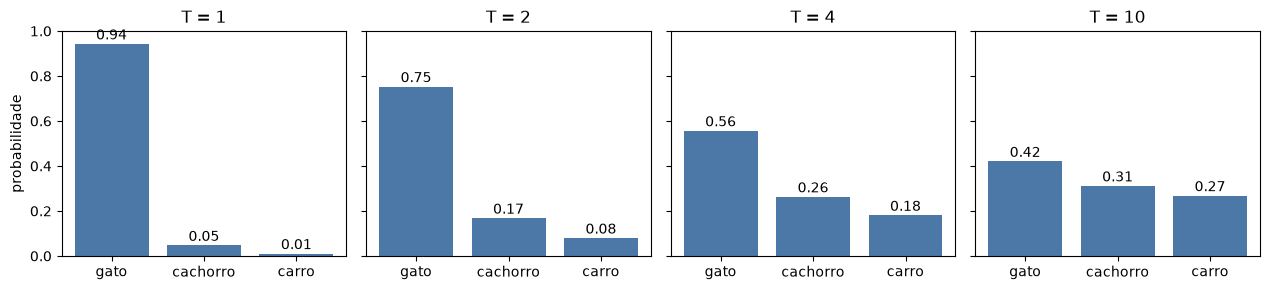

In [23]:
utils.plot_temperature([5.0, 2.0, 0.5], temps=(1, 2, 4, 10),
                         class_names=["gato", "cachorro", "carro"])

#### E no nosso problema (2 classes)?

Veja a probabilidade de pneumonia que o teacher atribui às imagens de validação, para vários T. Com T=1 quase tudo fica em 0 ou 1 (o teacher é muito confiante). Com T alto aparece a **gradação**: o teacher diz *quão* certo está de cada imagem, e isso é informação que o rótulo 0/1 não tem.

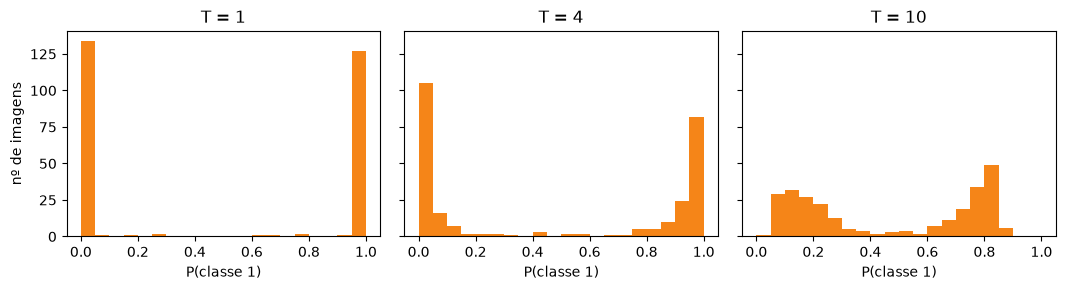

In [24]:
_, teacher_logits_val = utils.get_logits(teacher, val_loader, device)
utils.plot_prob_hist(teacher_logits_val, temps=(1, 4, 10))

### Knowledge Distillation Loss

A loss combina o aprendizado a partir dos rótulos reais com o conhecimento fornecido pelo Teacher:

$$
\mathcal{L}_{KD} = \alpha \mathcal{L}_{CE} + (1-\alpha)T^2\mathcal{L}_{KL}
$$

onde:

$$
\mathcal{L}_{CE} = CE(y, p_S)
\qquad
\mathcal{L}_{KL} = KL\left(\text{softmax}\left(\frac{z_T}{T}\right) \;\middle\|\; \text{softmax}\left(\frac{z_S}{T}\right)\right)
$$

- $y$: rótulo verdadeiro, $z_T$: logits do Teacher, $z_S$: logits do Student
- $T$: temperature, $\alpha$: peso do aprendizado supervisionado

#### Olhando a loss por dentro (um batch)

O fator $T^2$ existe porque dividir os logits por $T$ encolhe os gradientes do termo soft

In [35]:
import torch.nn.functional as F

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.squeeze().long().to(device)

with torch.no_grad():
    t_logits = teacher(images)
    s_logits = student(images)    

alpha = 0.75
hard = F.cross_entropy(s_logits, labels)
for T in (1, 4, 10):
    soft = F.kl_div(F.log_softmax(s_logits / T, dim=1),
                    F.softmax(t_logits / T, dim=1), reduction="batchmean") * T**2
    total = alpha * hard + (1 - alpha) * soft
    print(f"T={T:<2} hard={hard:.4f}  soft={soft:.4f}  total={total:.4f} "
        f"| utils.distillation_loss={utils.distillation_loss(s_logits, t_logits, labels, T, alpha):.4f}")

T=1  hard=0.2655  soft=0.2652  total=0.2654 | utils.distillation_loss=0.2654
T=4  hard=0.2655  soft=5.2586  total=1.5138 | utils.distillation_loss=1.5138
T=10 hard=0.2655  soft=15.9235  total=4.1800 | utils.distillation_loss=4.1800


### O papel de $\alpha$

O parâmetro $\alpha$ controla o equilíbrio entre duas fontes de informação:

$$
\boxed{\mathcal{L}_{KD} = \underbrace{\alpha \mathcal{L}_{CE}}_{\text{rótulo real}} + \underbrace{(1-\alpha)T^2\mathcal{L}_{KL}}_{\text{Teacher}}}
$$

- $\alpha$ maior -> maior importância para os rótulos reais.
- $\alpha$ menor -> maior importância para o Teacher.

#### Comparando as curvas de validação

Comparamos `val_loss` e `val_acc` (a `train_loss` do KD inclui o termo soft e não é comparável com a do baseline).

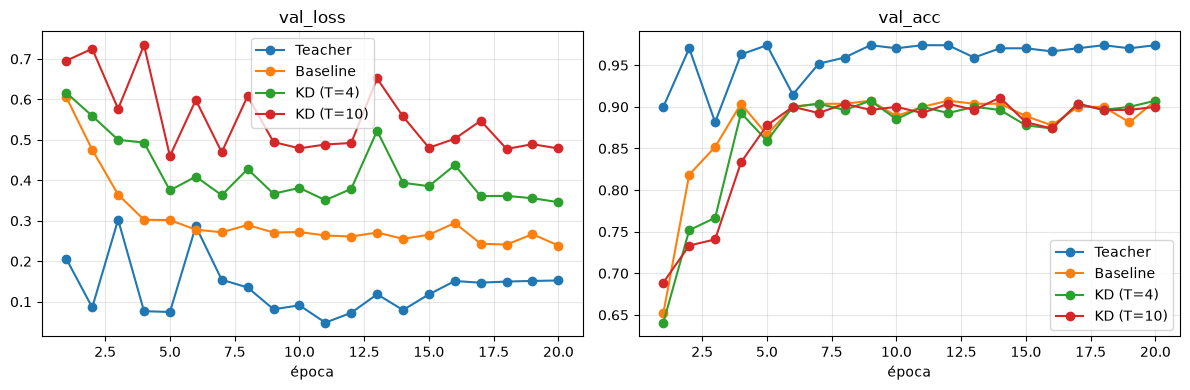

In [26]:
utils.plot_history({"Teacher": history_teacher,
                    "Baseline": history_baseline,
                    "KD (T=4)": history_student_kd_4,
                    "KD (T=10)": history_student_kd_10})

#### Sanity check: $\alpha = 1$ deve voltar ao baseline

Com $\alpha=1$ o termo do teacher desaparece e a loss vira apenas a CE. Com a mesma seed, as primeiras épocas devem ser (praticamente) idênticas às do baseline.

In [28]:
utils.set_seed(42)
student_a1 = utils.SmallCNN().to(device)
optimizer_a1 = torch.optim.Adam(student_a1.parameters(), lr=1e-3)
history_a1 = utils.train_knowledge_distillation(
    teacher, student_a1, train_loader, val_loader, epochs=3,
    T=4, alpha=1.0, optimizer=optimizer_a1, device=device, verbose=False)

print("Baseline (3 primeiras épocas):", [round(a, 4) for a in history_baseline["val_acc"][:3]])
print("KD com alpha=1:               ", [round(a, 4) for a in history_a1["val_acc"]])


Baseline (3 primeiras épocas): [0.6519, 0.8185, 0.8519]
KD com alpha=1:                [0.6519, 0.8185, 0.8481]


### Varredura de T e $\alpha$ (opcional)

Poucas épocas para caber no tempo da aula. **Escolhemos hiperparâmetros pela validação**; o teste só é usado uma vez, no notebook 04.

Epoch [1/5] Train Loss: 0.6348 Train Acc: 0.6491 Val Loss: 0.6034 Val Acc: 0.6481
Epoch [2/5] Train Loss: 0.5369 Train Acc: 0.7434 Val Loss: 0.4753 Val Acc: 0.8185
Epoch [3/5] Train Loss: 0.4177 Train Acc: 0.8196 Val Loss: 0.3644 Val Acc: 0.8519
Epoch [4/5] Train Loss: 0.3292 Train Acc: 0.8711 Val Loss: 0.3015 Val Acc: 0.9037
Epoch [5/5] Train Loss: 0.2986 Train Acc: 0.8867 Val Loss: 0.3017 Val Acc: 0.8667
Epoch [1/5] Train Loss: 0.6349 Train Acc: 0.6491 Val Loss: 0.6045 Val Acc: 0.6481
Epoch [2/5] Train Loss: 0.5371 Train Acc: 0.7422 Val Loss: 0.4754 Val Acc: 0.8185
Epoch [3/5] Train Loss: 0.4179 Train Acc: 0.8200 Val Loss: 0.3655 Val Acc: 0.8519
Epoch [4/5] Train Loss: 0.3296 Train Acc: 0.8699 Val Loss: 0.3021 Val Acc: 0.9037
Epoch [5/5] Train Loss: 0.2986 Train Acc: 0.8871 Val Loss: 0.3016 Val Acc: 0.8667
Epoch [1/5] Train Loss: 0.6350 Train Acc: 0.6491 Val Loss: 0.6042 Val Acc: 0.6481
Epoch [2/5] Train Loss: 0.5370 Train Acc: 0.7426 Val Loss: 0.4754 Val Acc: 0.8148
Epoch [3/5] Trai

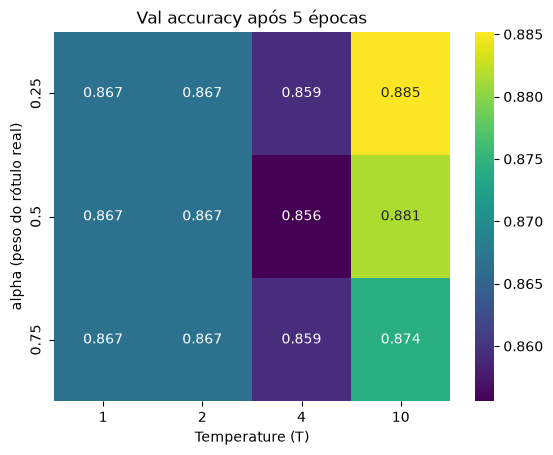

In [29]:
import pandas as pd
import seaborn as sns

SWEEP_EPOCHS = 5
temps, alphas = (1, 2, 4, 10), (0.25, 0.5, 0.75)
grid = pd.DataFrame(index=alphas, columns=temps, dtype=float)

for T in temps:
    for alpha in alphas:
        utils.set_seed(42)
        s = SmallCNN().to(device)
        opt = torch.optim.Adam(s.parameters(), lr=0.001)
        h = utils.train_knowledge_distillation(teacher, s, train_loader, val_loader, epochs=SWEEP_EPOCHS
                                               , T=T, alpha=alpha, optimizer=opt, device=device)
        # train_knowledge_distillation pode retornar dict ou tuple
        history = h[0] if isinstance(h, tuple) and isinstance(h[0], dict) else h
        grid.loc[alpha, T] = float(history["val_acc"][-1])
        del s, opt

sns.heatmap(grid, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Temperature (T)"); plt.ylabel("alpha (peso do rótulo real)")
plt.title(f"Val accuracy após {SWEEP_EPOCHS} épocas")
plt.show()

## Notebook 04 - Avaliação final

Compara teacher, student baseline e students com KD no conjunto de teste (nunca visto durante o treino). Os modelos são carregados do disco, então este notebook roda de forma independente.

In [30]:
from utils import (load_teacher, load_student, get_predictions, metrics_table,
                   compare_models, plot_confusion_matrices)

models = {
    "Teacher":            load_teacher("weights/teacher.pth", device),
    "Student (baseline)": load_student("weights/student_baseline.pth", device),
    "KD (T=4)":           load_student("weights/student_kd_4.pth", device),
    "KD (T=10)":          load_student("weights/student_kd_10.pth", device),
}

preds = {}
for name, model in models.items():
    y_true, preds[name] = get_predictions(model, test_loader, device)

results = metrics_table(y_true, preds)
results

,Accuracy,Recall,Precision,MCC
Teacher,0.8910,0.9915,0.8256,0.7983
Student (baseline),0.8226,0.8889,0.7849,0.6510
KD (T=4),0.8333,0.8974,0.7955,0.6722
KD (T=10),0.8312,0.8803,0.8016,0.6656


**Como ler as métricas:** em diagnóstico por imagem, o *Recall* da classe Pneumonia mede quantos casos doentes o modelo encontra (falso negativo = doente mandado para casa). O *MCC* resume a matriz de confusão inteira e é robusto a desbalanceamento.

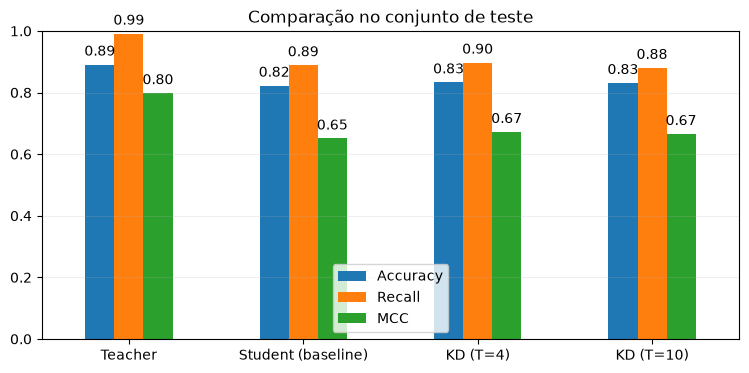

In [31]:
ax = results[["Accuracy", "Recall", "MCC"]].plot.bar(
    figsize=(9, 4),
    ylim=(0, 1),
    rot=0
)

plt.title("Comparação no conjunto de teste")
plt.grid(axis="y", alpha=0.2)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.show()

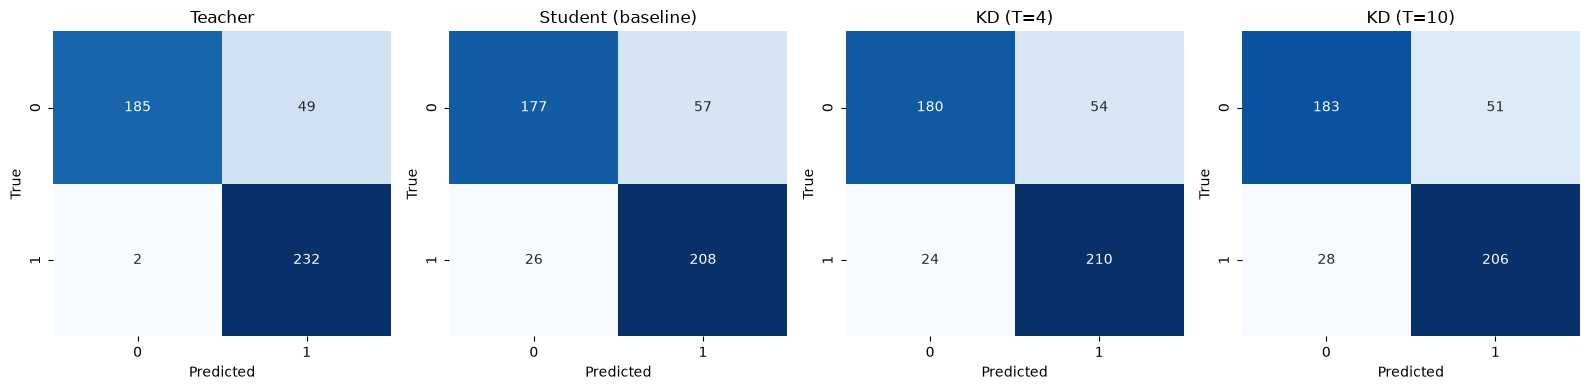

In [32]:
plot_confusion_matrices(y_true, preds)

### Quanto o student se parece com o teacher?

*Fidelidade* = % de imagens em que o student dá a **mesma resposta** que o teacher. A hipótese do KD é que o student treinado com KD imita melhor o teacher.

In [33]:
for name in ["Student (baseline)", "KD (T=4)", "KD (T=10)"]:
    print(f"{name:<20} concorda com o teacher em {(preds[name] == preds['Teacher']).mean():.2%} das imagens")

Student (baseline)   concorda com o teacher em 80.77% das imagens
KD (T=4)             concorda com o teacher em 81.41% das imagens
KD (T=10)            concorda com o teacher em 80.77% das imagens


### Qualidade vs. custo

In [34]:
compare_models(models, device)

,Parâmetros,Tamanho (MB),Latência (ms/batch)
Teacher,11171266.0,44.69,6.50
Student (baseline),23426.0,0.09,1.67
KD (T=4),23426.0,0.09,1.62
KD (T=10),23426.0,0.09,1.61


### Conclusões e limitações

- Compare a qualidade (tabela de métricas) com o custo (tabela acima): o student com KD é muito menor e mais rápido que o teacher.
- O teste tem poucas imagens; diferenças pequenas entre baseline e KD podem ser ruído. O ideal é repetir com várias seeds e reportar média e desvio.
- Neste curso usamos KD **offline** (teacher fixo). Próximos passos: KD online, KD de camadas intermediárias (*feature distillation*), KD em outros domínios (NLP).